In [1]:
from iChem.utils import load_smiles, binary_fps
from iChem.bblean.hierarchical import hierarchical_bitbirch
from iChem.visualization import cluster_connect_vis, cluster_dendrogram, dendrogram_bitbirch
from iChem.visualization.mol_images import smiles_to_grid_image

/home/klopezperez/iChem/iChem/bblean/similarity.py:101: UserWarning: C++ optimized similarity calculations not available, falling back to python implementation
  warnings.warn(


In [2]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

from iChem.bblean.bitbirch import BitBirch
from iChem.bblean.similarity import jt_sim_matrix_packed

import numpy as np


In [8]:
smiles = load_smiles("../tests/data/mcule_natural_products.smi", standarize=False)
smiles = smiles[:25]
fps = binary_fps(smiles=smiles, fp_type="ECFP4", return_invalid=False, standarize=False)

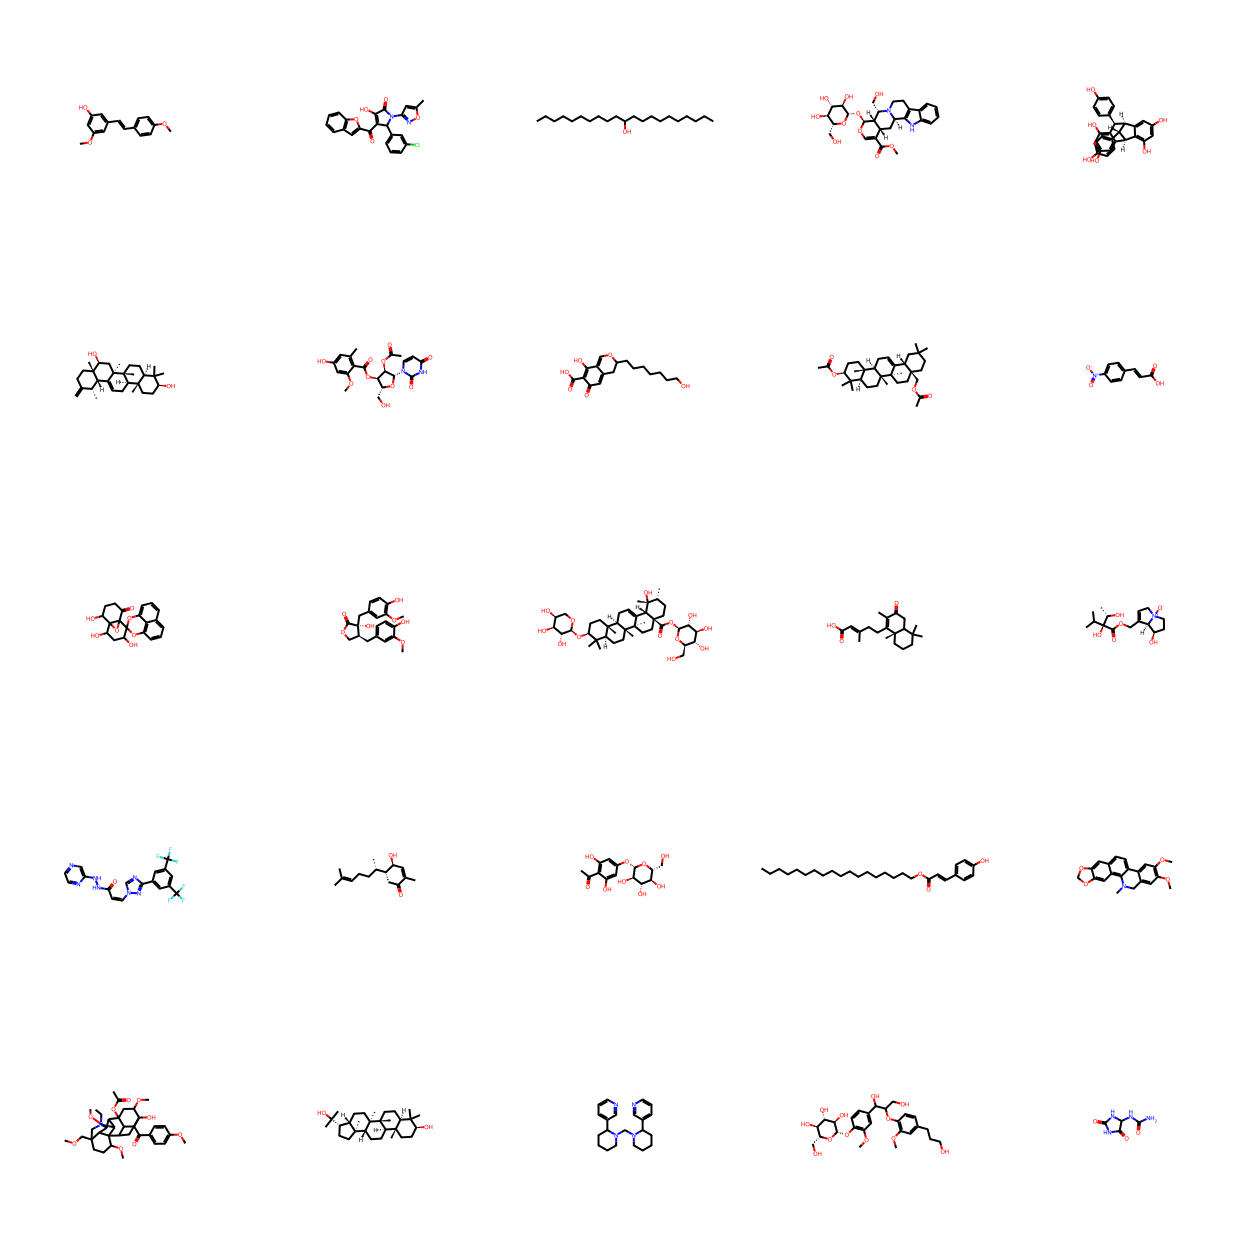

In [9]:
smiles_to_grid_image(smiles, mols_per_row=5, sub_img_size=(250, 250), standarize=True)

Step 0: Threshold = 0.252, Number of clusters = 24
Step 1: Threshold = 0.242, Number of clusters = 24
Step 2: Threshold = 0.231, Number of clusters = 24
Step 3: Threshold = 0.221, Number of clusters = 23
Step 4: Threshold = 0.210, Number of clusters = 21
Step 5: Threshold = 0.200, Number of clusters = 20
Step 6: Threshold = 0.189, Number of clusters = 20
Step 7: Threshold = 0.179, Number of clusters = 19
Step 8: Threshold = 0.168, Number of clusters = 15
Step 9: Threshold = 0.158, Number of clusters = 13
Step 10: Threshold = 0.147, Number of clusters = 11
Step 11: Threshold = 0.137, Number of clusters = 10
Step 12: Threshold = 0.126, Number of clusters = 8
Step 13: Threshold = 0.116, Number of clusters = 7
Step 14: Threshold = 0.105, Number of clusters = 4
Step 15: Threshold = 0.095, Number of clusters = 2
Step 16: Threshold = 0.084, Number of clusters = 1
Step 17: Threshold = 0.074, Number of clusters = 1
Step 18: Threshold = 0.063, Number of clusters = 1
Step 19: Threshold = 0.053, N

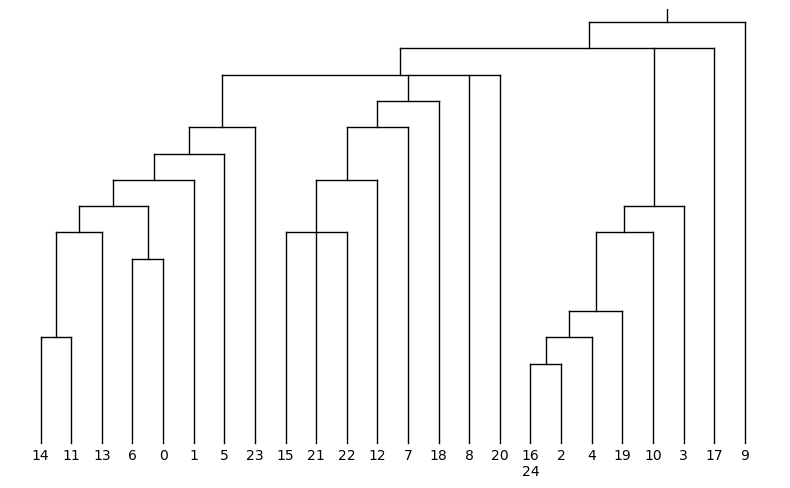

In [18]:
hierarchichal_clusters = hierarchical_bitbirch(fingerprints=fps, steps=25)

# Visualize the cluster connections
dendrogram_bitbirch(hierarchichal_clusters)

In [19]:
sim_matrix = jt_sim_matrix_packed(fps)
dist_matrix = 1 - sim_matrix

In [20]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

# Get the condensed distance matrix (upper triangular form in 1D array)
condensed_dist_matrix = squareform(dist_matrix)


# Compute the linkage matrix directly
Z = linkage(condensed_dist_matrix,
            method="average")

{'icoord': [[55.0, 55.0, 65.0, 65.0],
  [45.0, 45.0, 60.0, 60.0],
  [75.0, 75.0, 85.0, 85.0],
  [52.5, 52.5, 80.0, 80.0],
  [35.0, 35.0, 66.25, 66.25],
  [25.0, 25.0, 50.625, 50.625],
  [95.0, 95.0, 105.0, 105.0],
  [135.0, 135.0, 145.0, 145.0],
  [125.0, 125.0, 140.0, 140.0],
  [115.0, 115.0, 132.5, 132.5],
  [100.0, 100.0, 123.75, 123.75],
  [155.0, 155.0, 165.0, 165.0],
  [175.0, 175.0, 185.0, 185.0],
  [205.0, 205.0, 215.0, 215.0],
  [195.0, 195.0, 210.0, 210.0],
  [180.0, 180.0, 202.5, 202.5],
  [235.0, 235.0, 245.0, 245.0],
  [225.0, 225.0, 240.0, 240.0],
  [191.25, 191.25, 232.5, 232.5],
  [160.0, 160.0, 211.875, 211.875],
  [111.875, 111.875, 185.9375, 185.9375],
  [37.8125, 37.8125, 148.90625, 148.90625],
  [15.0, 15.0, 93.359375, 93.359375],
  [5.0, 5.0, 54.1796875, 54.1796875]],
 'dcoord': [[0.0,
   np.float64(0.711864406779661),
   np.float64(0.711864406779661),
   0.0],
  [0.0,
   np.float64(0.7568181818181818),
   np.float64(0.7568181818181818),
   np.float64(0.7118644067

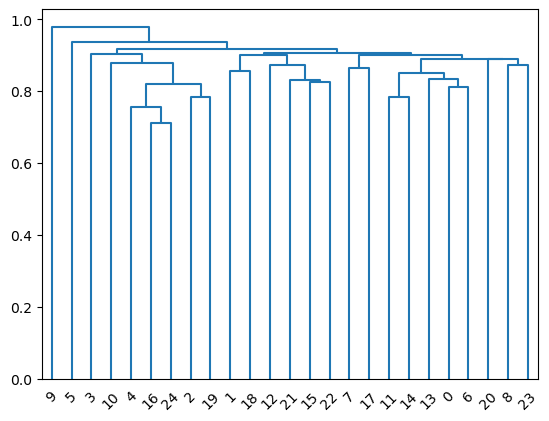

In [21]:
# Plot the dendrogram for the clustering using sklearn
dendrogram(Z)

In [7]:
cluster_dendrogram(smiles, min_size=0, steps = 5)

Step 0: Threshold = 0.308, Number of clusters = 21
Step 1: Threshold = 0.231, Number of clusters = 18
Step 2: Threshold = 0.154, Number of clusters = 9
Step 3: Threshold = 0.077, Number of clusters = 1
Step 4: Threshold = 0.000, Number of clusters = 1


Step 0: Threshold = 0.308, Number of clusters = 21
Step 1: Threshold = 0.205, Number of clusters = 14
Step 2: Threshold = 0.103, Number of clusters = 4
Step 3: Threshold = 0.000, Number of clusters = 1
Saving cluster images to: /tmp/ichem_clusters_p33olawh



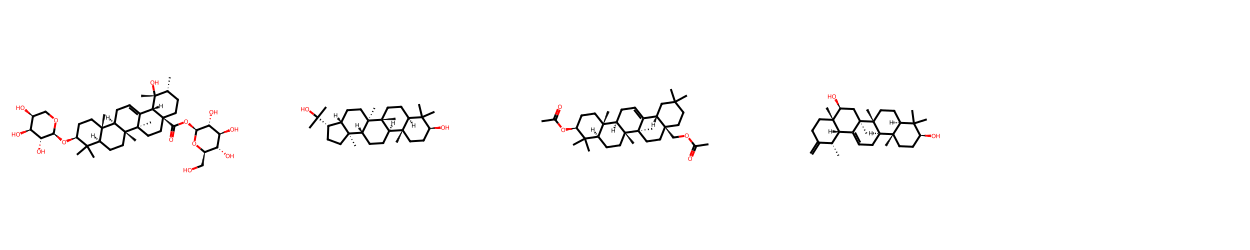
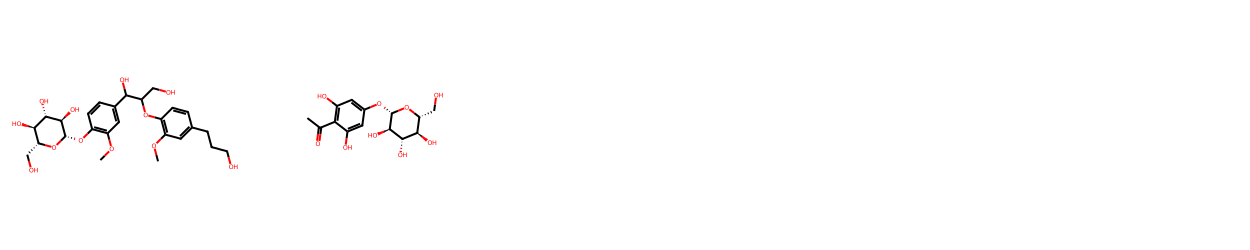
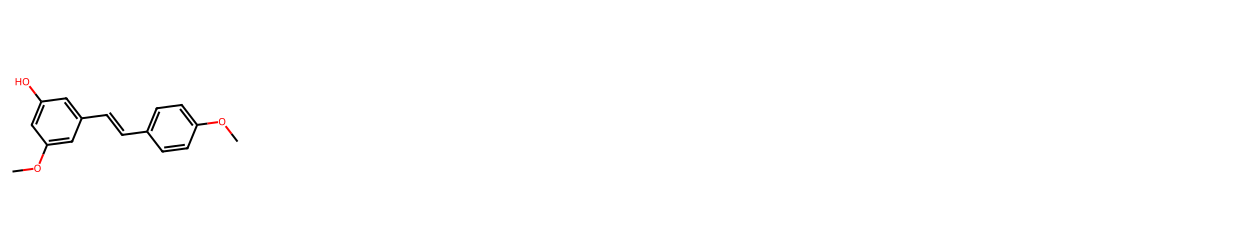
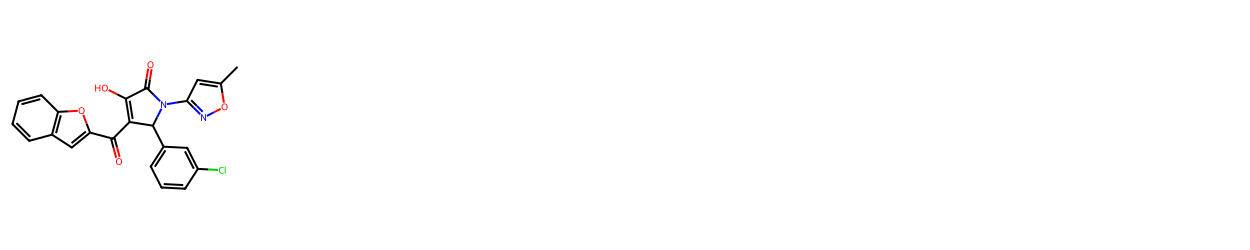
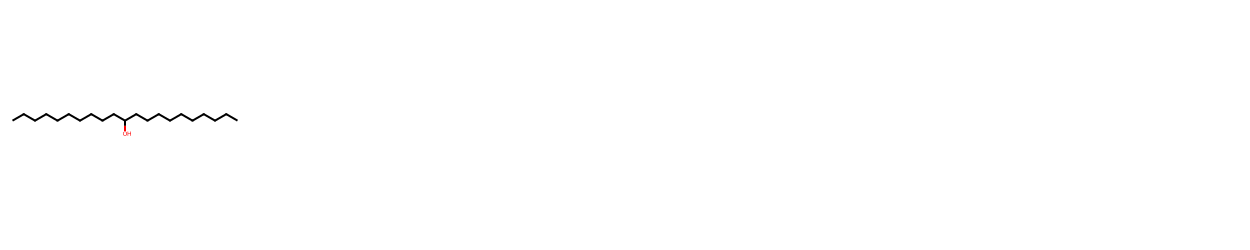
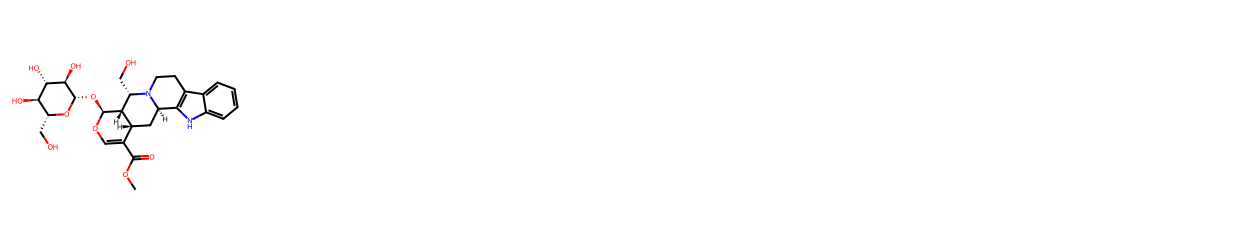
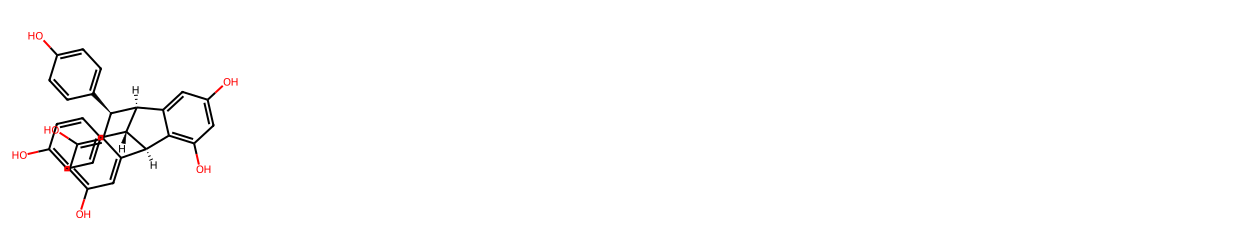
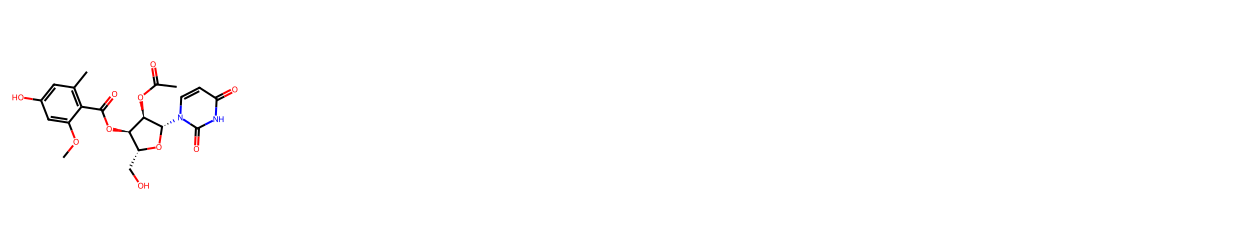
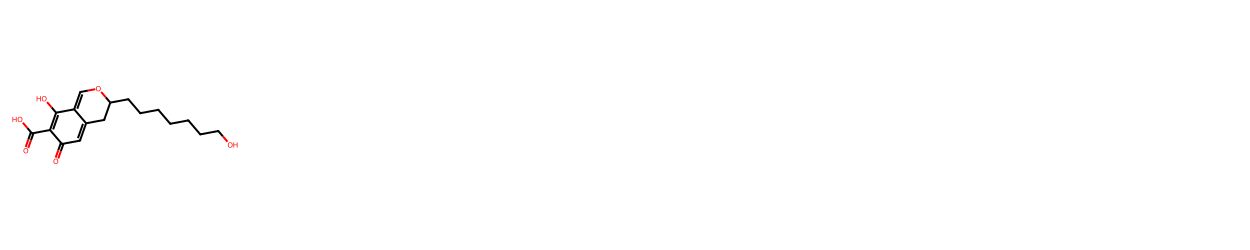
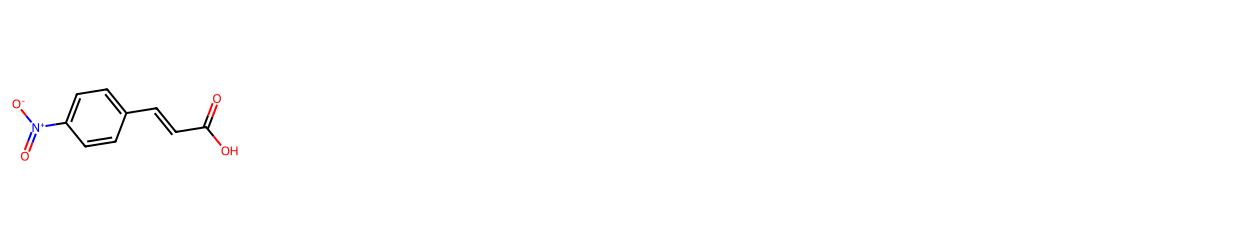
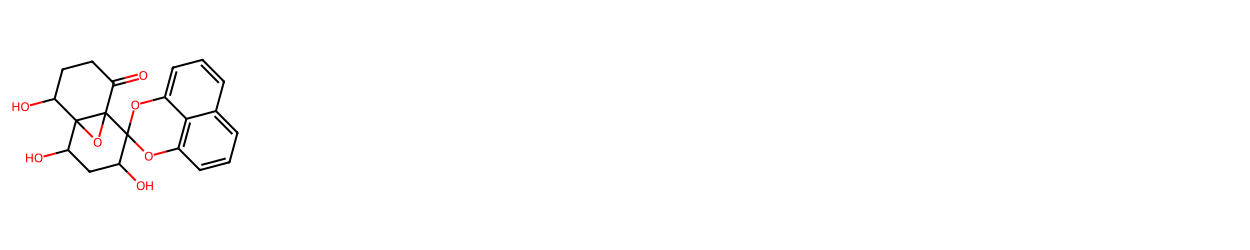
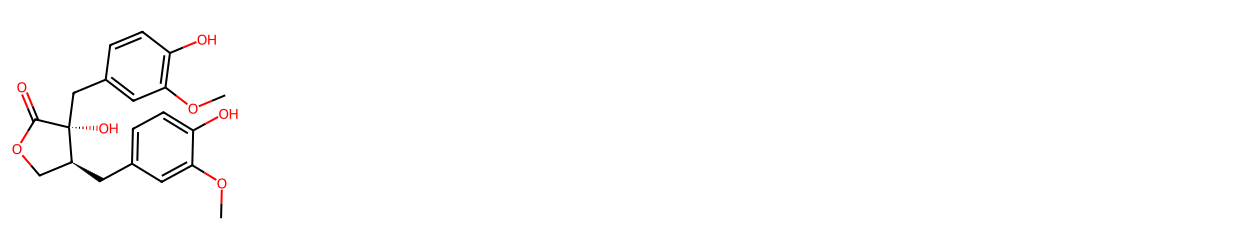
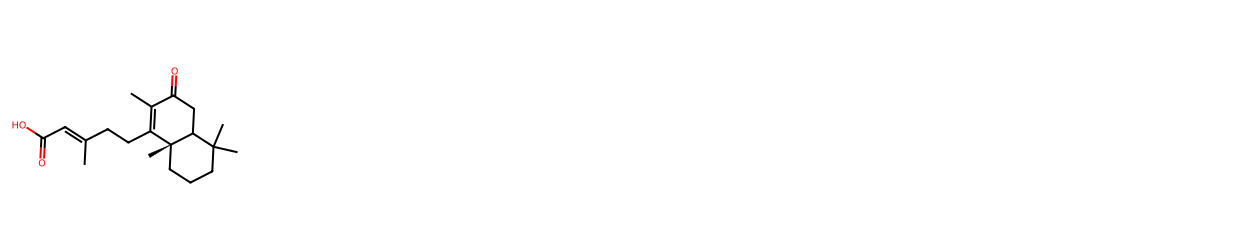
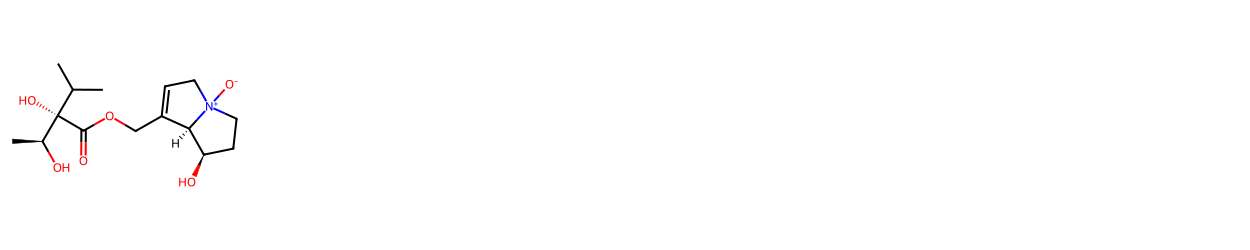
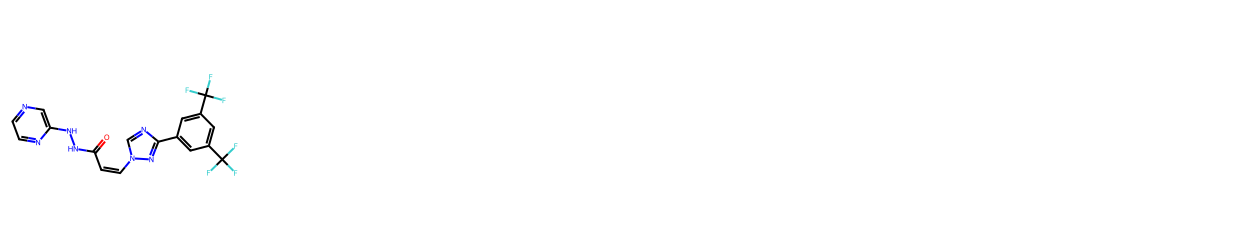
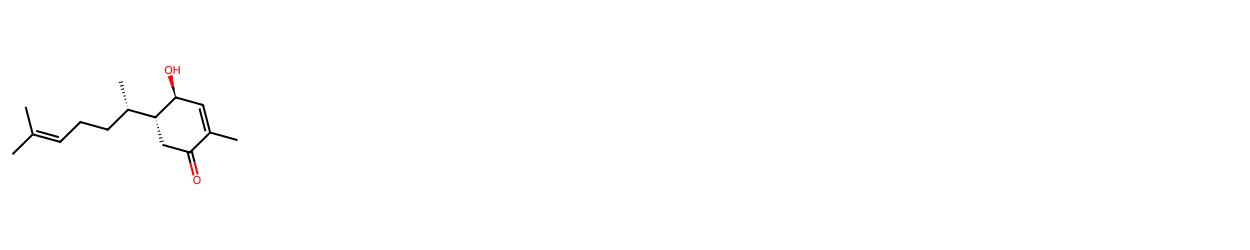
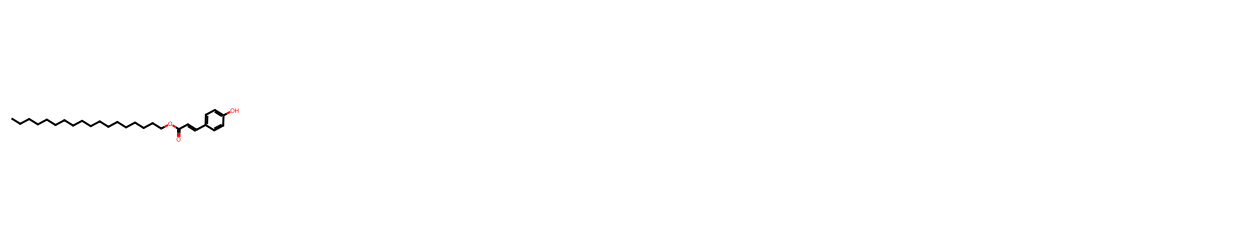
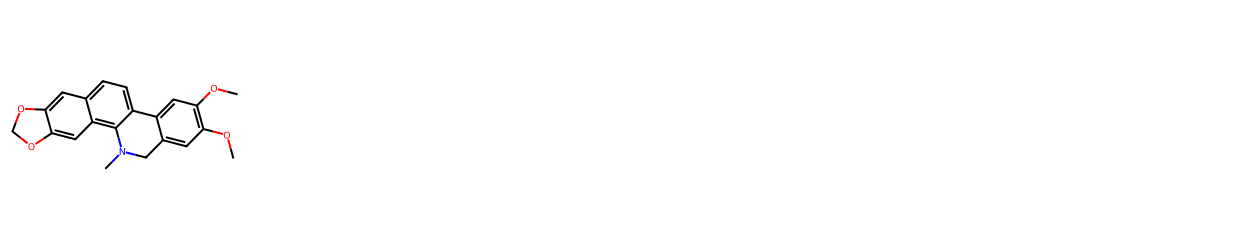
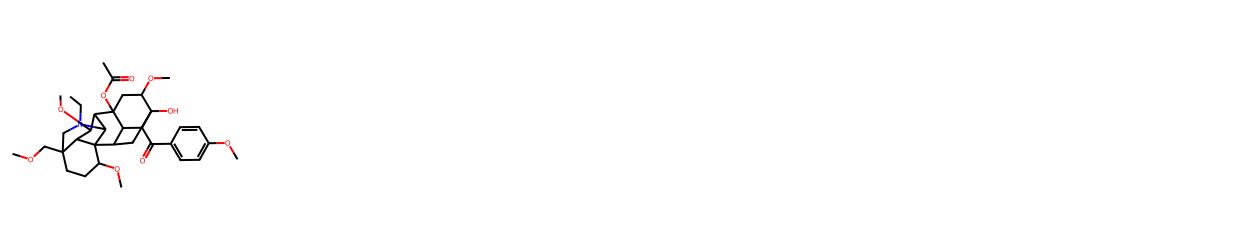
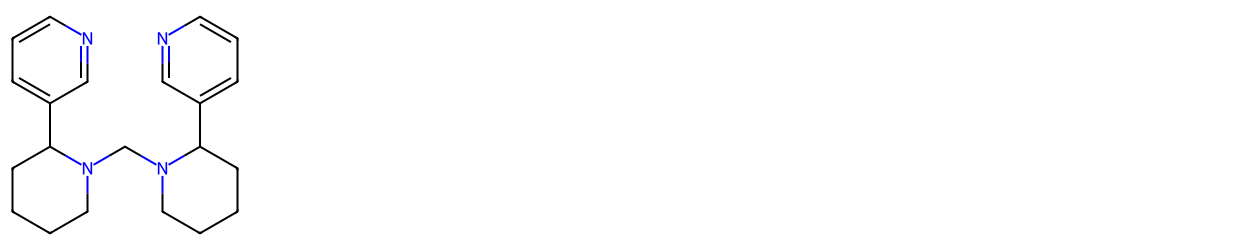
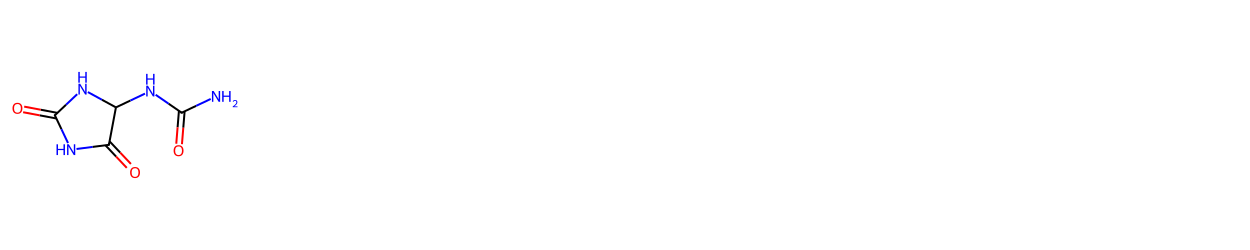
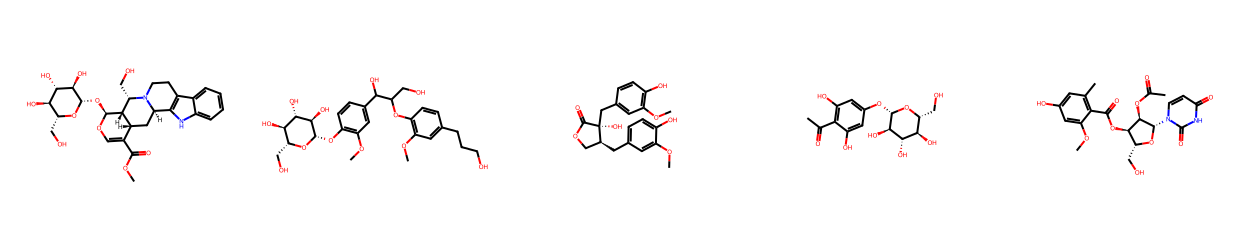
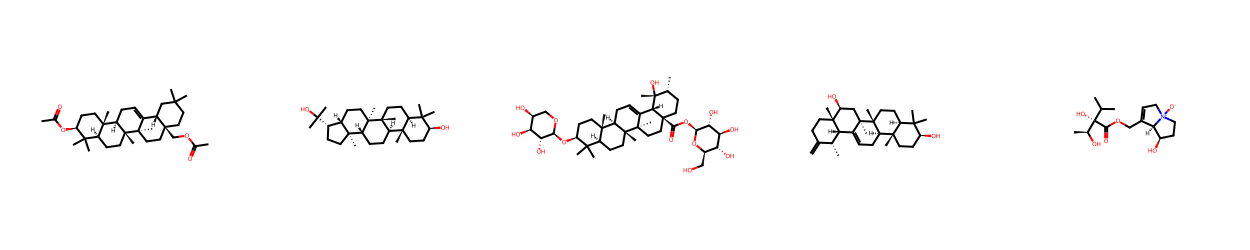
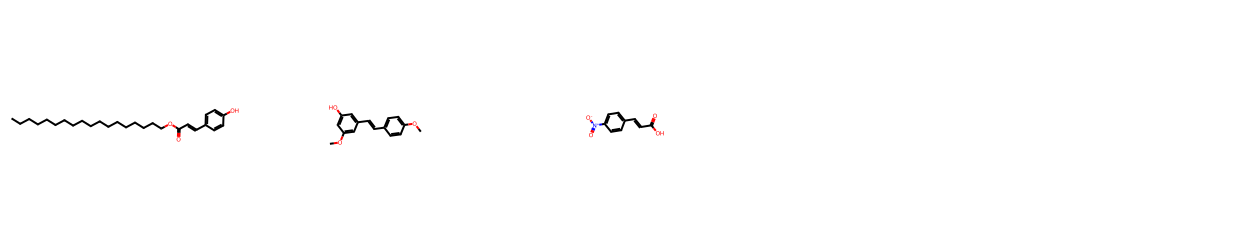
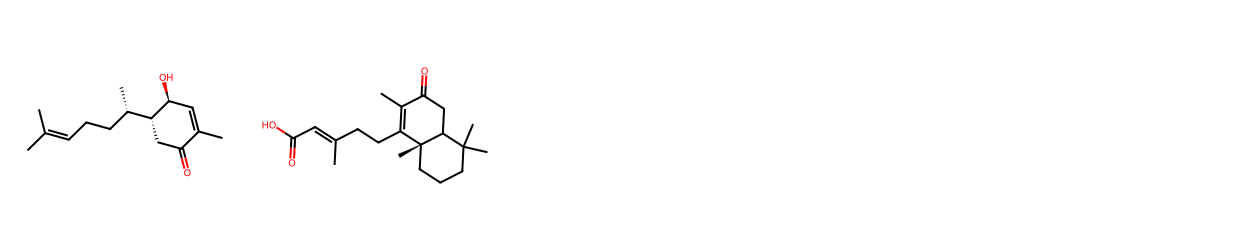
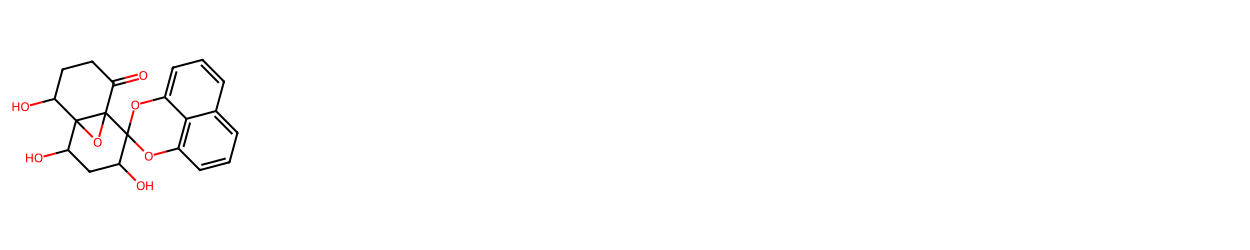
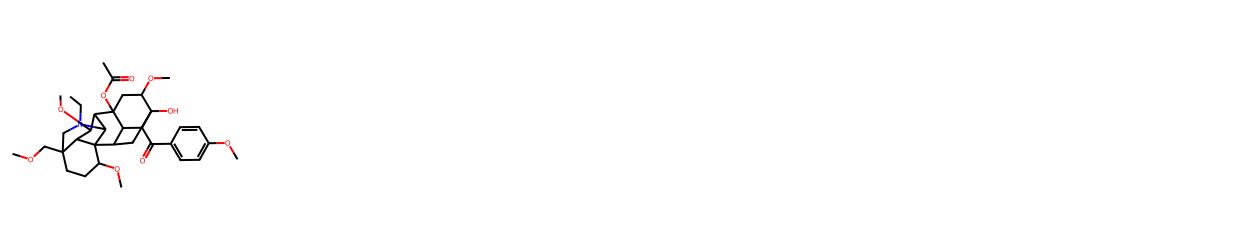
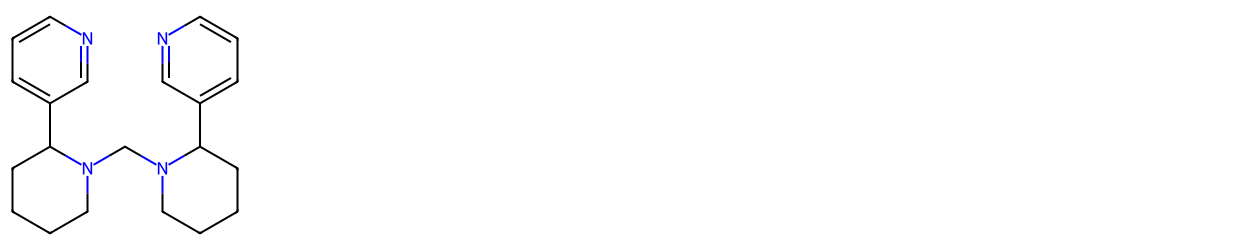
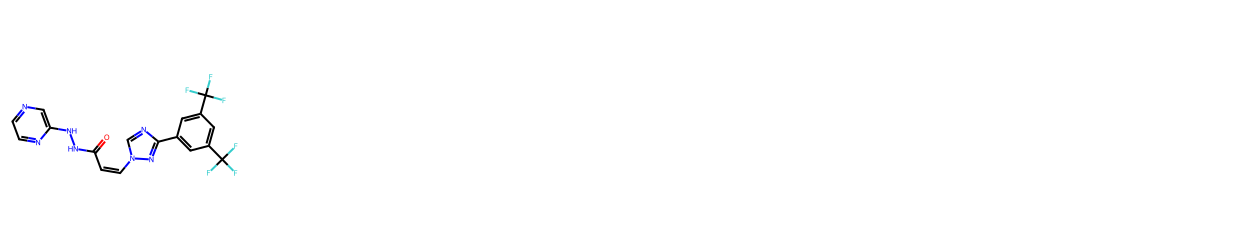
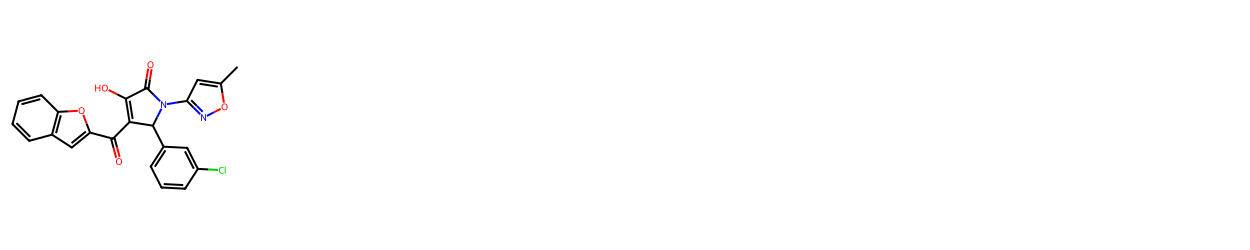
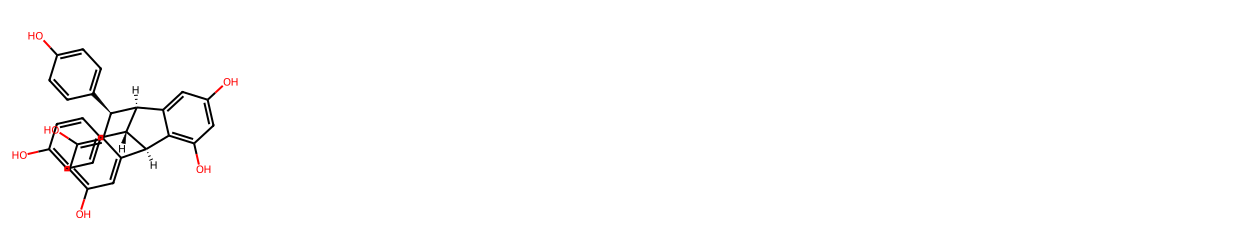
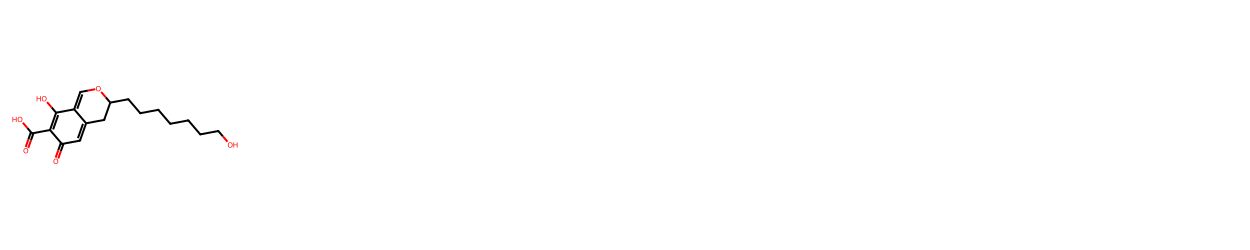
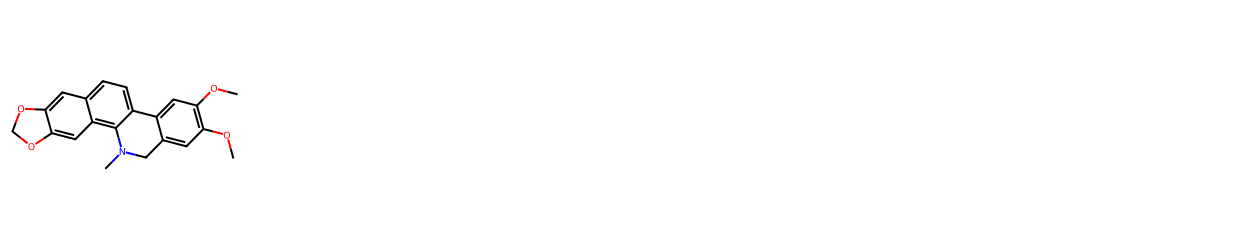
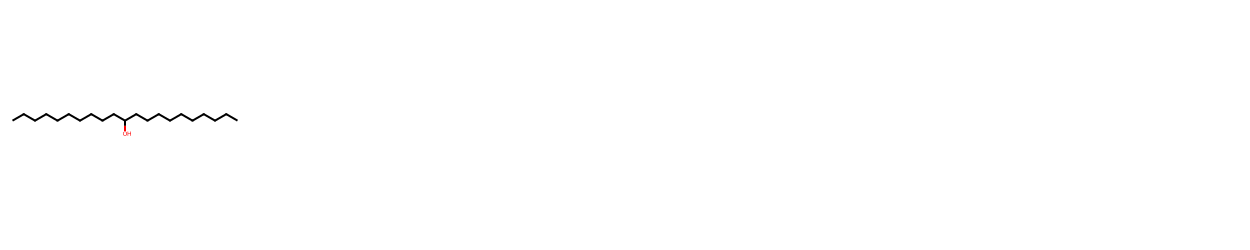
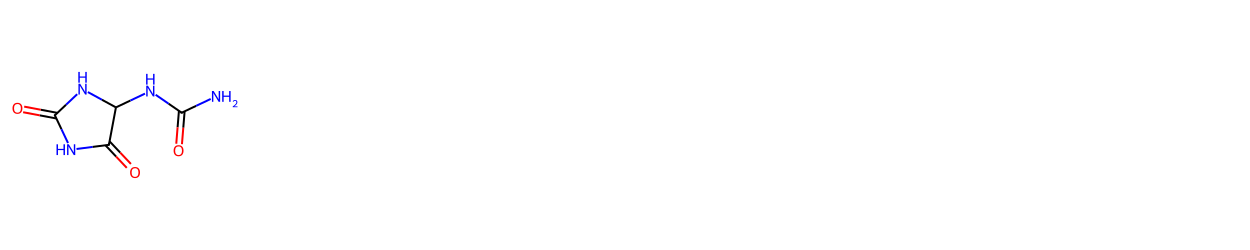
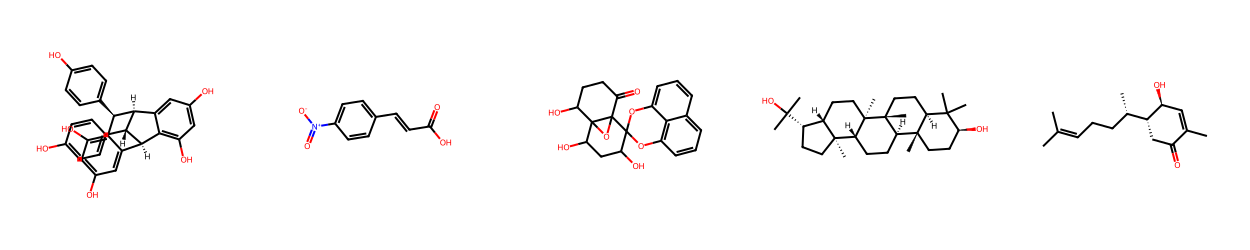
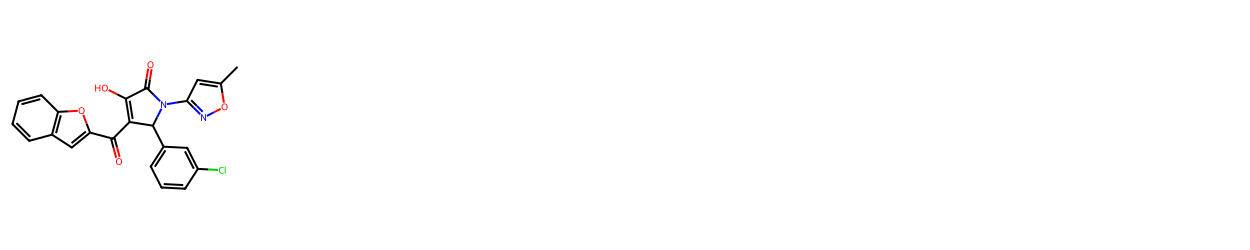
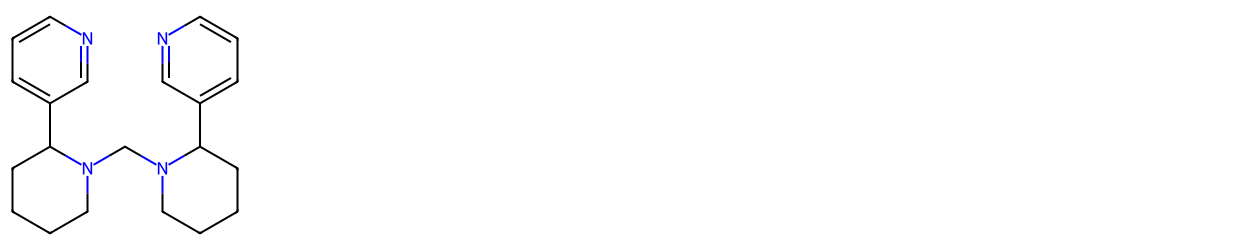
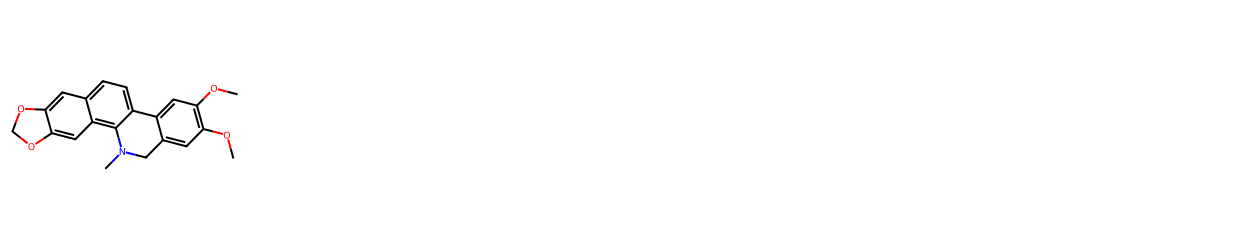
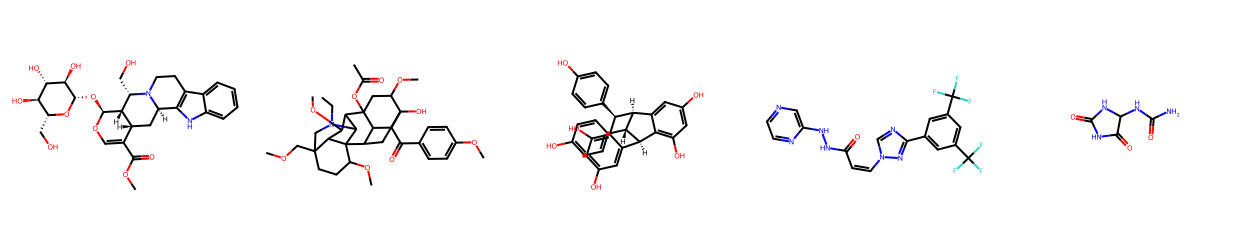

In [18]:
cluster_connect_vis(smiles, min_size=0, steps = 4)